<a href="https://colab.research.google.com/github/MarianaCastrillonM004/Integracion-de-prospectiva-y-datos/blob/main/Parcial_Riesgo_Operacional_FallasTecnologicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parcial: Evaluación del Riesgo Operacional en Canales Electrónicos


Como analistas de riesgos de una entidad financiera líder, han recibido la base de datos histórica de Eventos de Riesgo Tecnológico ocurridos en los canales electrónicos (App móvil, Sucursal Virtual, Cajeros).

**Objetivo:** Transformar la base de datos histórica de eventos de riesgo tecnológico en una herramienta de decisión gerencial que permita cuantificar la exposición económica y la eficacia de los controles actuales.

Op-Var: Es el 99.9% de los datos en la distribucion de las pérdidas (LDA). Los que se quedan por fuera de ese porcentage en prospectiva de riesgos, generalemnete son las pérdias catastróficas, es decir aquellas que no son gestionables y es mejor que administren los seguros.


**Variables:**

* Fecha: día en que ocurrió la falla tecnológica.
* Transacciones_Diarias: volumen total de transacciones procesadas ese día en los canales digitales.
* Valor_Transado_MM: valor total transado en millones de USD ese día.
* Frecuencia: número de transacciones fallidas en ese evento.
* Severidad: pérdida económica en MM USD asociada a esa falla.
* Descripcion_Evento: texto que describe el tipo de falla ocurrida.

## 0. Carga de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [2]:
def clusterizacion(Xi):
    XC = np.random.choice(Xi, size=5)
    XC = np.sort(XC)  # Semillas
    nc = np.zeros((len(Xi), 1)) #Columna vacia para rellenar con clusters

    for k in range(len(Xi)):
        d = np.abs(XC - Xi[k])  # Distancia de un dato a cada semilla
        nc[k] = np.argmin(d)
        nc2 = np.int32(nc[k])
        XC[nc2] = (XC[nc2] + Xi[k]) / 2  # Actualizar centroide

    return XC, nc

## 1. Carga y Exploración de Datos

In [6]:
nxl = '/content/drive/MyDrive/UNIVERSIDAD/Enfasis/Archivos I&P/5. Riesgo Operacional FallasTecnológicas.xlsx'
np.random.seed(42)

# Hoja principal de eventos
XDB = pd.read_excel(nxl, sheet_name='Fallas Tecnológicas')
# Hoja de catálogo de riesgos (niveles)
XRiesgos = pd.read_excel(nxl, sheet_name='Riesgos') #, index_col=0
# Hoja de gestión
XGestion = pd.read_excel(nxl, sheet_name='Gestión')

# Renombrar columnas de forma estandarizada
XDB.columns = ['Fecha', 'Transacciones_Diarias', 'Valor_Transado_MM',
                'Frecuencia', 'Severidad', 'Descripcion_Evento']
XDB.head()

,Fecha,Transacciones_Diarias,Valor_Transado_MM,Frecuencia,Severidad,Descripcion_Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


In [7]:
# Obtenemos la variable de frecuencia
Xf = np.array(XDB['Frecuencia'])
XCf, ncf = clusterizacion(Xf)

# Obtenemos la variable de Severidad
# Usamos valor absoluto para evitar negativos (errores de datos)
Xs = np.abs(np.array(XDB['Severidad']))
XCs, ncs = clusterizacion(Xs)

# PÉRDIDAS AGREGADAS (LDA): Frecuencia × Severidad
LDA = Xf*Xs
XClda, nclda = clusterizacion(LDA)

# Creamos un dataframe para descargar
df = pd.DataFrame(np.column_stack((Xf,ncf,Xs,ncs,LDA,nclda,XDB.iloc[:,5])))
df.columns = ['Freq', 'Nivel_f','Sev.','Nivel_S','LDA','Nivel_LDA','Riesgos']
df.head()

,Freq,Nivel_f,Sev.,Nivel_S,LDA,Nivel_LDA,Riesgos
0,1,0.0,0.5374,0.0,0.5374,0.0,"Errores visuales menores, problemas de usabili..."
1,4,0.0,1.1978,2.0,4.7912,2.0,"Errores en la interfaz de usuario, fallas en f..."
2,5,1.0,0.4269,0.0,2.1345,1.0,"Errores visuales menores, problemas de usabili..."
3,6,1.0,1.0814,1.0,6.4884,3.0,"Errores en la interfaz de usuario, fallas en f..."
4,7,2.0,1.2105,2.0,8.4735,4.0,"Errores en la interfaz de usuario, fallas en f..."


## 2. Clasificación de Eventos (K-Means Simplificado)

Usamos la función de clusterización de clase para clasificar frecuencia (transacciones fallidas) y severidad (valor pérdida) en 5 niveles.

In [9]:
# Proceso de clústerización
XC=np.random.choice(Xf, size = 5)
XC = np.sort(XC) # Semillas de la cústerización
nc=np.zeros((len(Xf)))

for k in range (len(Xf)): # El primer dato en primera semilla
  d=np.abs(XC-Xf[0]) # Distancia de un dato a cada semilla
  nc[0]=np.argmin(d)
  nc2=np.int32(nc[0])
  XC[nc2,]=(XC[nc2,]+Xf[0])/2

## 3. Arquitectura de Matrices
### 3.1 Matriz de Frecuencia

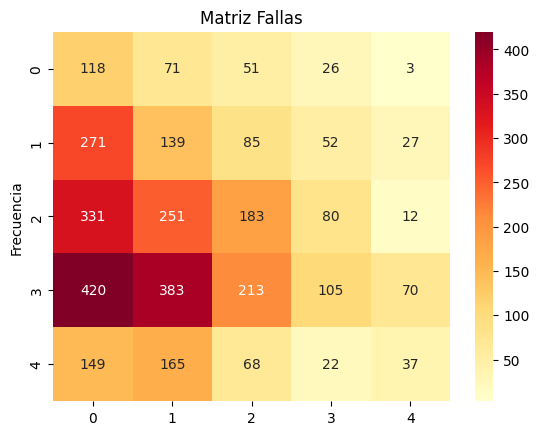

In [10]:
MEf = np.zeros((5, 5))
MEs = np.zeros((5, 5))

for k in range(len(Xf)):
    nf = np.int32(df.iloc[k, 1])  # Fila de frecuencia
    nc = np.int32(df.iloc[k, 3])   # Columna de severidad
    MEf[nf,nc] = MEf[nf,nc]+Xf[k]
    MEs[nf,nc] = (MEs[nf,nc]+Xs[k,])/2 # Costo promedio # Severidad promedio

plt.figure()
sns.heatmap(MEf, annot=True, fmt='.0f', cmap='YlOrRd')
plt.ylabel('Frecuencia')
plt.title('Matriz Fallas')
plt.show()

### 3.2 Matriz de Severidad

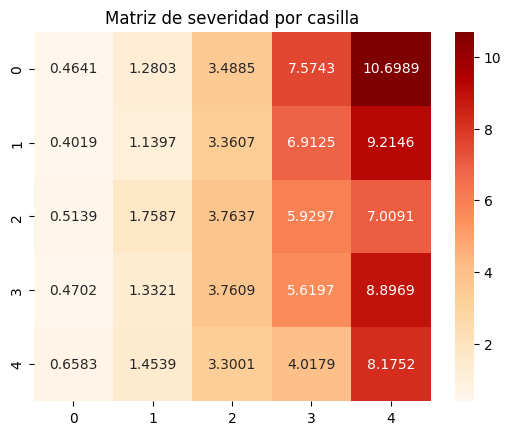

In [11]:
plt.figure()
sns.heatmap(MEs, annot=True, fmt='.4f', cmap='OrRd')
plt.title('Matriz de severidad por casilla')
plt.show()

#El método aplana las diferencias entre frecuencias altas y bajas porque
#trata cada evento igual independientemente de cuántos hay en esa celda.

## 3. Matrices de Impacto y Gestión
### 3.1 Matriz de Impacto

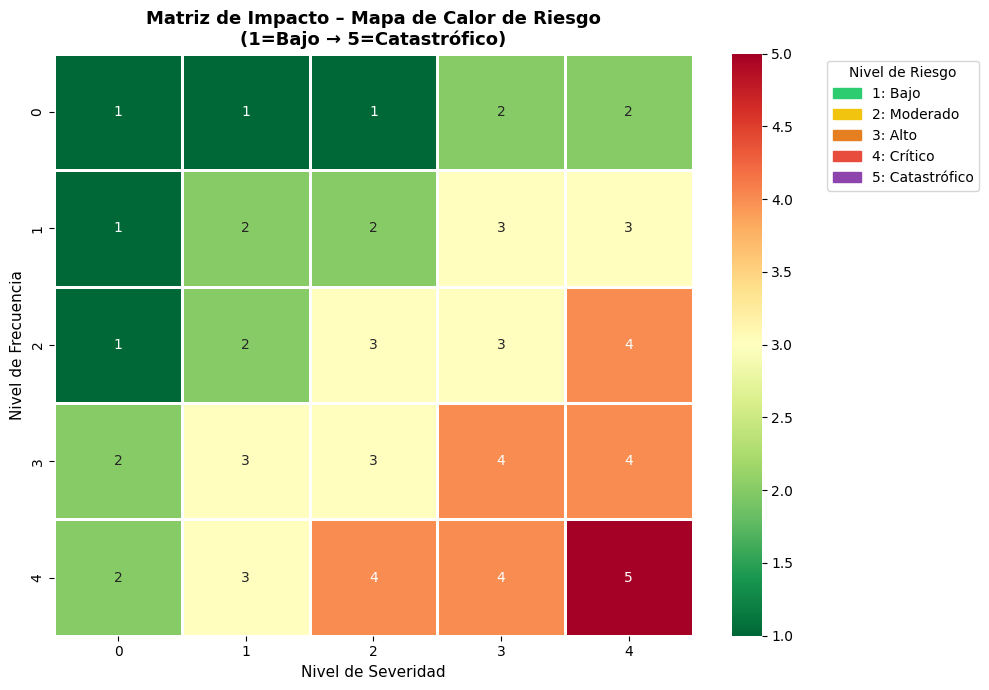

In [12]:
# Matriz de impacto estándar (igual que en clase)
MI= np.array([[1,1,1,2,2],
             [1,2,2,3,3],
             [1,2,3,3,4],
             [2,3,3,4,4],
             [2,3,4,4,5]])

#------------------------------------------------------------------#
# Personalización del Gráfico
#------------------------------------------------------------------#

# Colores semáforo por nivel
colores_impacto = {
    1: '#2ecc71',  # Verde
    2: '#f1c40f',  # Amarillo
    3: '#e67e22',  # Naranja
    4: '#e74c3c',  # Rojo
    5: '#8e44ad'   # Morado
}
niveles_nombre = {1:'Bajo', 2:'Moderado', 3:'Alto', 4:'Crítico', 5:'Catastrófico'}

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(MI, annot=True, fmt='d', cmap='RdYlGn_r',
            linewidths=1, linecolor='white', ax=ax,
            vmin=1, vmax=5)
plt.xlabel('Nivel de Severidad', fontsize=11)
plt.ylabel('Nivel de Frecuencia', fontsize=11)
plt.title('Matriz de Impacto – Mapa de Calor de Riesgo\n(1=Bajo → 5=Catastrófico)', fontsize=13, fontweight='bold')

# Leyenda de colores
patches = [mpatches.Patch(color=v, label=f'{k}: {niveles_nombre[k]}') for k,v in colores_impacto.items()]
ax.legend(handles=patches, loc='upper left', bbox_to_anchor=(1.2, 1), title='Nivel de Riesgo')

plt.tight_layout()
plt.show()

### 3.2 Matriz de Gestión (Riesgo Residual)

El nivel de gestión representa los controles implementados. Un mayor nivel de gestión reduce las pérdidas catastróficas.

Ingresar el nivel de Gestión (1,2,3,4):2

Nivel de Gestión seleccionado: 2 – Medio


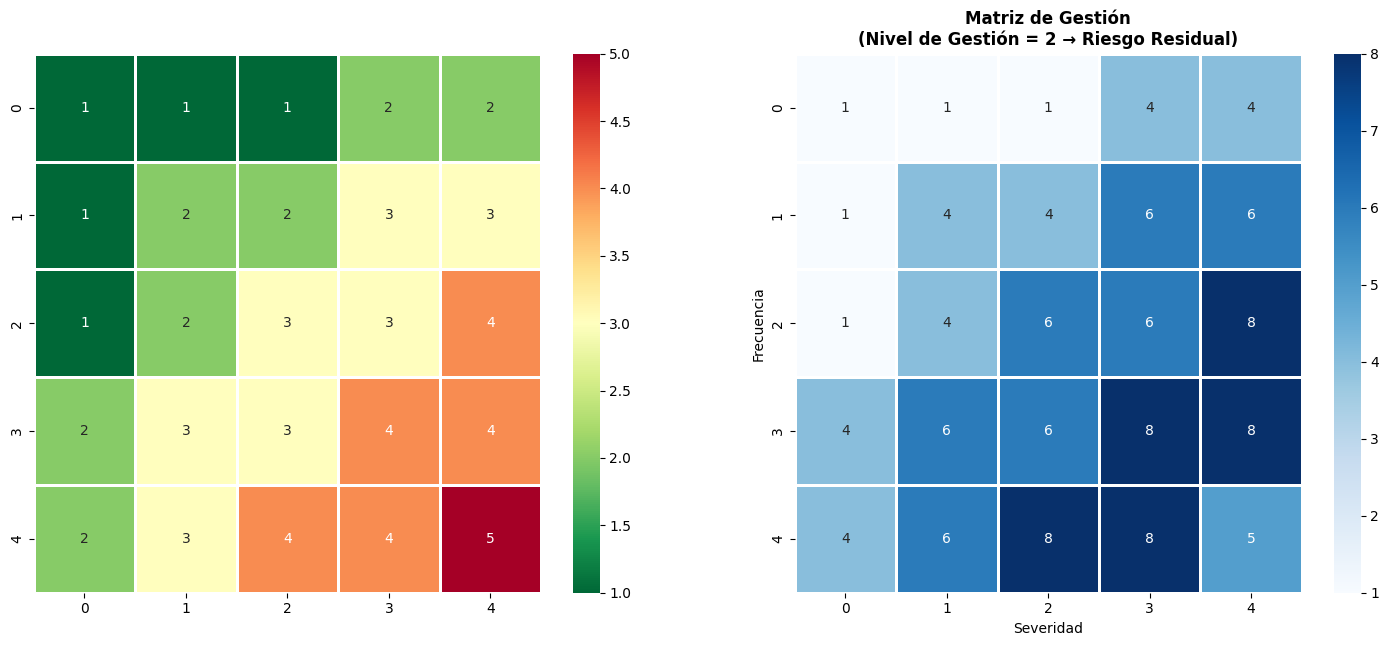

In [13]:
NG=np.int32(input("Ingresar el nivel de Gestión (1,2,3,4):"))

MG = np.copy(MI)
for i in range(5):
    for j in range(5):
        if MG[i, j] > 1 and MG[i, j] < 5:  # Solo zonas intermedias
            MG[i, j] = MG[i, j] * NG

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#------------------------------------------------------------------#
# Personalización del Gráfico
#------------------------------------------------------------------#

sns.heatmap(MI, annot=True, fmt='d', cmap='RdYlGn_r',
            linewidths=1, linecolor='white', ax=axes[0], vmin=1, vmax=5)
plt.title(f'Matriz de Impacto\n(Riesgo Inherente – Sin Gestión)', fontsize=12, fontweight='bold')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')

sns.heatmap(MG, annot=True, fmt='d', cmap='Blues',
            linewidths=1, linecolor='white', ax=axes[1])
plt.title(f'Matriz de Gestión\n(Nivel de Gestión = {NG} → Riesgo Residual)', fontsize=12, fontweight='bold')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')


print(f"\nNivel de Gestión seleccionado: {NG} – {['','Bajo','Medio','Moderado','Alto','Crítico'][NG]}")


In [14]:
#1. Perdida esperada
ps=np.mean(MEs)
print("El promedio simple de severidad por atender una Falla tecnológica es:", ps)

#2. Como no todos las Fallas tecnológicas tienen la misma frecuencia
#Hay pocos fallas que sufren pérdidas extremas
pp=np.round(np.sum(MEf*MEs)/np.sum(MEf),3)
print("El promedio ponderado de severidad por atender una Falla tecnológica es:",pp,"USD")

#3. Se procede a determinar la perdidad ponderada teniendo igualmente la matriz de impacto - Nivel de riego
pnr=np.sum(MEf*MEs*MI)/np.sum(MEf*MI)
print("El promedio ponderado de severidad por atender una Falla tecnológica teniendo en cuenta el nivel de riesgo es:",pnr,"USD")

#4. Se procede a determinar la pérdida ponderada teniendo igualmente la matriz de gestion
png=np.sum(MEf*MEs*MI)/np.sum(MEf*MG)
print(f"El promedio ponderado de severidad por atender una Falla tecnológica teniendo en cuenta un nivel de gestion {NG} es:",png,"USD")

print(f"  Reducción por gestión NG={NG}: {pnr - png:.6f} MM USD")
reduccion_pct = (pnr - png) / pnr * 100
print(f"  Porcentaje de reducción:{reduccion_pct:.1f}%")

El promedio simple de severidad por atender una Falla tecnológica es: 4.047830871818241
El promedio ponderado de severidad por atender una Falla tecnológica es: 2.175 USD
El promedio ponderado de severidad por atender una Falla tecnológica teniendo en cuenta el nivel de riesgo es: 2.8118425171752874 USD
El promedio ponderado de severidad por atender una Falla tecnológica teniendo en cuenta un nivel de gestion 2 es: 1.5079406984639605 USD
  Reducción por gestión NG=2: 1.303902 MM USD
  Porcentaje de reducción:46.4%


### 5. Operational Value at Risk (OpVaR) al 99.9%

El **OpVaR** es el cuantil extremo de la distribución de pérdidas. Al 99.9% indica que solo el 0.1% de los eventos podrían superar ese valor. Se calcula comparando el escenario **No Gestionado (Inherente)** vs **Gestionado (Residual)**.

El limite de las perdidas esperadas (C1) es: 9.45111269614836
El limite de las perdidas no esperadas (C2) es: 4.7912
El limite de las perdidas catastróficas (C3) es: 102.9021000000008
El numero de fallas con perdidas menores a C1 son 1952
El numero de fallas con perdidas mayores a OpVar son 10
El numero de fallas con perdidas gestionables son 1370
El porcentaje de perdidas menores a C1 es: 58.58 %
El porcentaje de perdidas gestionables es: 41.12 %
El porcentaje de perdidas mayores a C3 es: 0.3 %


Text(0.5, 0, 'Pérdidas')

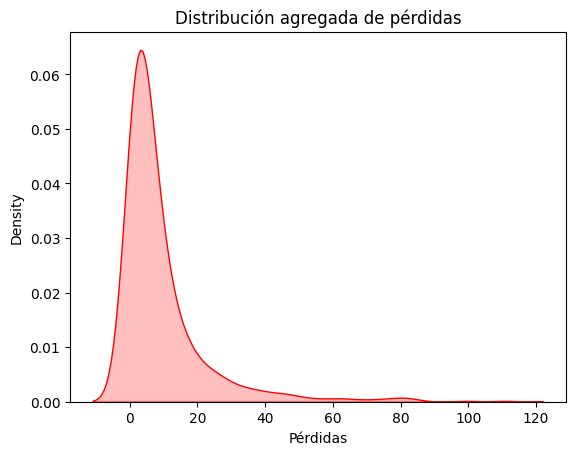

In [36]:
#Se procede con la gráfica de la distribucion de pérdidas

LDA=np.array(df.iloc[:,4])
LC1=np.mean(LDA); print("El limite de las perdidas esperadas (C1) es:", LC1) # Son las perdidas peromedio, perdidas calculadas
LC2=np.percentile(LDA, 50); print("El limite de las perdidas no esperadas (C2) es:", LC2) #Tambien conociedo como perdidas gestionables
OpVar=np.percentile(LDA, 99.9); print("El limite de las perdidas catastróficas (C3) es:", OpVar) #Estas pérdidas son tan malas que es mejor llamar al seguro

#Contabilizamos el numero de fallas por categoría de riesgo
nc_c1= np.sum(df[df.iloc[:, 4]<LC1].iloc[:,0])
print("El numero de fallas con perdidas menores a C1 son", nc_c1)
nc_c3= np.sum(df[df.iloc[:, 4]>OpVar].iloc[:,0])
print("El numero de fallas con perdidas mayores a OpVar son", nc_c3)
nc_c2=np.sum(df.iloc[:,0])-nc_c1-nc_c3
print("El numero de fallas con perdidas gestionables son", nc_c2)

#Los valores porcentuales del riesgo son:
print("El porcentaje de perdidas menores a C1 es:", np.round(nc_c1/np.sum(df.iloc[:,0])*100,2),"%")
print("El porcentaje de perdidas gestionables es:", np.round(nc_c2/np.sum(df.iloc[:,0])*100,2),"%")
print("El porcentaje de perdidas mayores a C3 es:", np.round(nc_c3/np.sum(df.iloc[:,0])*100,2),"%")

plt.figure()
sns.kdeplot(LDA, fill=True, color='Red')
plt.title('Distribución agregada de pérdidas')
plt.xlabel('Pérdidas')

Me puedes ingresar el nivel de gestión [1, 2, 3, 4]2
El número de contenedores en C1 luego de una gestión 1: 2 es: 2652
El número de contenedores en C3 luego de una gestión 1: 2 es: 0
El número de contenedores en C2 luego de una gestión 1: 2 es: 670
El porcentaje de perdidas menores a C1 es: 79.59 %
El porcentaje de perdidas gestionables es: 20.11 %
El porcentaje de perdidas mayores a C3 es: 0.0 %
El número de contenedores que migran de C2-C1 son: 700
La Pérdida Promedio es: 2.8118425171752874
El costo de la Gestión de una Unidad (falla) es: 0.251803200645176
El valor capturado financiero es: 1615.7652811194548
El número de toneladas de GEI por año: 16.15765281119455


Text(0.5, 0, 'Pérdidas')

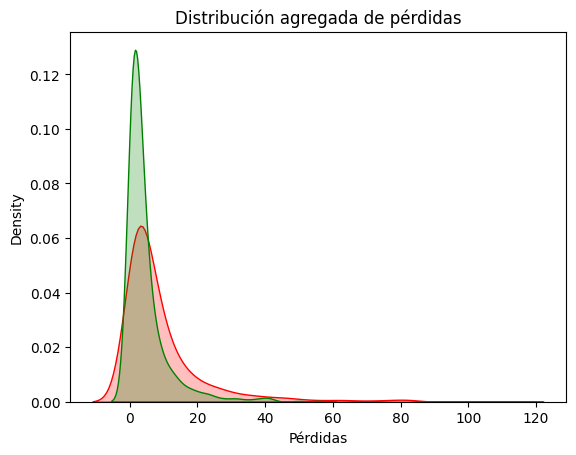

In [39]:
#La idea es pasar riesgos de C2 a C1

nimp = np.array(df.iloc[:,5]+1) #Nivel de lda
ngest = np.int32(input("Me puedes ingresar el nivel de gestión [1, 2, 3, 4]"))
ng2 = nimp*ngest
df['Nivel_LDA'] = nimp
df['Nivel Gestión'] = ng2

#Se procede a determinar la distribución de perdidas gestionadas
LDA_G = LDA*(nimp/ng2)
df['LDA_Gestionada'] = LDA_G

#Procedemos a contar las fallas
nc_c1_g = np.sum(df[LDA_G < LC1].iloc[:,0])
print(f"El número de contenedores en C1 luego de una gestión 1: {ngest} es: {nc_c1_g}")
nc_c3_g = np.sum(df[LDA_G > OpVar].iloc[:,0])
print(f"El número de contenedores en C3 luego de una gestión 1: {ngest} es: {nc_c3_g}")
nc_c2_g = np.sum(df.iloc[:,0])-nc_c1_g-nc_c3
print(f"El número de contenedores en C2 luego de una gestión 1: {ngest} es: {nc_c2_g}")\

print("El porcentaje de perdidas menores a C1 es:", np.round(nc_c1_g/np.sum(df.iloc[:,0])*100,2),"%")
print("El porcentaje de perdidas gestionables es:", np.round(nc_c2_g/np.sum(df.iloc[:,0])*100,2),"%")
print("El porcentaje de perdidas mayores a C3 es:", np.round(nc_c3_g/np.sum(df.iloc[:,0])*100,2),"%")

#Valor Capturado Financiero
ncg = nc_c1_g-nc_c1
print("El número de contenedores que migran de C2-C1 son:", ncg)
PProm = 2.8118425171752874
CGest = 0.251803200645176 #Costo Gestión - Hoja 3 fallas
VCapt = ncg*(PProm - (CGest*ngest)) #Calor Capturado - Evito que los contenedores sean C3
print("La Pérdida Promedio es:", PProm)
print("El costo de la Gestión de una Unidad (falla) es:", CGest)
print("El valor capturado financiero es:", VCapt)
TGEI = 100 #Esto me pagan por tonelada capturada de GEI (Gases Efecto Invernadero)
TCaptGEI = VCapt/TGEI
print("El número de toneladas de GEI por año:", TCaptGEI)

plt.figure()
sns.kdeplot(LDA, fill=True, color='Red')
sns.kdeplot(LDA_G, fill = True, color = 'Green')
plt.title('Distribución agregada de pérdidas')
plt.xlabel('Pérdidas')

## 6. Tablero de Auditoría – Filtro Dinámico

Permite seleccionar cualquier celda de la matriz de pérdidas y ver el listado detallado de eventos que la componen.

In [15]:
#DF Filtrado con el nivel de impacto y frecuencia que quiero
fila=np.int32(input("Ingresar el nivel de frecuencia:"))
columna=np.int32(input("Ingresar el nivel de impacto:"))
df[(df.iloc[:,1]==fila)&(df.iloc[:,3]==columna)]

Ingresar el nivel de frecuencia:2
Ingresar el nivel de impacto:2


,Freq,Nivel_f,Sev.,Nivel_S,LDA,Nivel_LDA,Riesgos
4,7,2.0,1.2105,2.0,8.4735,4.0,"Errores en la interfaz de usuario, fallas en f..."
23,5,2.0,1.3368,2.0,6.684,2.0,"Errores en la interfaz de usuario, fallas en f..."
44,6,2.0,1.2693,2.0,7.6158,2.0,"Errores en la interfaz de usuario, fallas en f..."
67,5,2.0,1.6576,2.0,8.288,1.0,"Errores en la interfaz de usuario, fallas en f..."
82,5,2.0,1.5423,2.0,7.7115,2.0,"Errores en la interfaz de usuario, fallas en f..."
110,6,2.0,1.6892,2.0,10.1352,2.0,"Errores en la interfaz de usuario, fallas en f..."
115,5,2.0,1.9072,2.0,9.536,2.0,"Errores en la interfaz de usuario, fallas en f..."
143,6,2.0,2.1317,2.0,12.7902,2.0,"Errores en la interfaz de usuario, fallas en f..."
157,6,2.0,2.6077,2.0,15.6462,2.0,"Degradación del rendimiento por varias horas, ..."
191,5,2.0,2.2048,2.0,11.024,2.0,"Errores en la interfaz de usuario, fallas en f..."


In [38]:
import ipywidgets as widgets
from IPython.display import display, HTML
#from ipywidgets import interact, IntSlider

def tablero_auditoria(nivel_frecuencia, nivel_severidad, mostrar_n=20):
    """
    Tablero de Auditoría – Filtro Dinámico por celda de la matriz de Pérdidas Agregadas (MLDA).

    Parámetros:
    -----------
    nivel_frecuencia : int (0-4)
        Representa el nivel de frecuencia (fila de la matriz).
    nivel_severidad  : int (0-4)
        Representa el nivel de severidad (columna de la matriz).
    mostrar_n : int
        Número máximo de eventos detallados a mostrar (por defecto 20).
    """
    nivel_labels_frecuencia = {
        0: 'Muy Baja',
        1: 'Baja',
        2: 'Media',
        3: 'Alta',
        4: 'Muy Alta'
    }
    nivel_labels_severidad = {
        0: 'Muy Baja',
        1: 'Baja',
        2: 'Media',
        3: 'Alta',
        4: 'Muy Alta'
    }

    # Filtrar eventos de la celda seleccionada usando el DataFrame 'df'
    # Convert Nivel_f and Nivel_S to int for accurate comparison
    mascara = (df['Nivel_f'].astype(int) == nivel_frecuencia) & (df['Nivel_S'].astype(int) == nivel_severidad)
    eventos_celda = df[mascara].copy()

    # Get the impact level from the MI matrix
    impacto_nivel = MI[nivel_frecuencia, nivel_severidad]
    impacto_nombre = niveles_nombre[impacto_nivel]

    # Encabezado
    print("\n" + "█" * 70)
    print(f"  🔍 TABLERO DE AUDITORÍA – FILTRO DINÁMICO")
    print(f"  Celda seleccionada (Matriz LDA): Frecuencia [{nivel_frecuencia}] × Severidad [{nivel_severidad}]")
    print(f"  Nivel de Frecuencia: {nivel_labels_frecuencia[nivel_frecuencia]} | Nivel de Severidad: {nivel_labels_severidad[nivel_severidad]}")
    print(f"  Nivel de Impacto (MI): {impacto_nivel} – {impacto_nombre}")
    print("█" * 70)

    if eventos_celda.empty:
        print("  ⚠️  No hay eventos registrados en esta celda para los niveles seleccionados.")
        return

    # Resumen estadístico
    print(f"\n  📊 RESUMEN DE LA CELDA")
    print(f"  {'─'*50}")
    print(f"  Total de eventos:            {len(eventos_celda):>8}")
    print(f"  Frecuencia total (Txns):     {eventos_celda['Freq'].sum():>8.0f}")
    print(f"  Frecuencia promedio (Txns):  {eventos_celda['Freq'].mean():>8.2f}")
    print(f"  Pérdida total (MM USD):      {eventos_celda['Sev.'].sum():>8.4f}")
    print(f"  Pérdida promedio (MM USD):   {eventos_celda['Sev.'].mean():>8.4f}")
    print(f"  Pérdida máxima (MM USD):     {eventos_celda['Sev.'].max():>8.4f}")
    print(f"  LDA total (MM USD):          {eventos_celda['LDA'].sum():>8.4f}")

    # Descripción del tipo de evento predominante
    desc_mode = eventos_celda['Riesgos'].mode()
    if not desc_mode.empty:
        print(f"\n  📋 TIPO DE EVENTO PREDOMINANTE:")
        predominant_desc = desc_mode[0]
        print(f"  {predominant_desc[:120]}..." if len(predominant_desc) > 120 else f"  {predominant_desc}")
    else:
        print("\n  📋 No se pudo determinar un tipo de evento predominante.")

    # Listado detallado de eventos
    print(f"\n  📅 LISTADO DETALLADO DE EVENTOS (mostrando los primeros {min(mostrar_n, len(eventos_celda))} de {len(eventos_celda)} )")
    print(f"  {'─'*100}")

    # Reconstruct the detailed events using XDB's original columns and df's LDA
    eventos_detalle = XDB.loc[eventos_celda.index, ['Fecha', 'Frecuencia', 'Severidad', 'Descripcion_Evento']].copy()
    eventos_detalle['LDA'] = eventos_celda['LDA'] # Add the calculated LDA from df

    # Ensure column names match for display
    eventos_detalle.columns = ['Fecha', 'Txns Fallidas', 'Pérdida (MM)', 'Descripción del Evento', 'LDA (MM)']

    # Format Date
    eventos_detalle['Fecha'] = pd.to_datetime(eventos_detalle['Fecha']).dt.strftime('%Y-%m-%d')

    tabla_mostrar = eventos_detalle.head(mostrar_n).reset_index(drop=True)
    tabla_mostrar.index += 1

    display(HTML(tabla_mostrar.to_html(classes='table table-striped table-hover', escape=False)))
    print(f"  {'─'*100}")

print("✅ Función tablero_auditoria() definida.")
print("\n  Utiliza los sliders a continuación para seleccionar una celda en la matriz de pérdidas:")

#create interactive sliders for frequency and severity levels
#interact(tablero_auditoria,
#         nivel_frecuencia=IntSlider(min=0, max=4, step=1, value=2, description='Nivel Frecuencia'),
#         nivel_severidad=IntSlider(min=0, max=4, step=1, value=2, description='Nivel Severidad'),
#         mostrar_n=widgets.fixed(20)); # Fix mostrar_n to 20 for this interface

✅ Función tablero_auditoria() definida.

  Utiliza los sliders a continuación para seleccionar una celda en la matriz de pérdidas:


## 7. Resumen Ejecutivo – Dashboard Gerencial

## Informe Ejecutivo: Evaluación del Riesgo Operacional en Canales Electrónicos


### 1. Arquitectura de Matrices
*   **Matriz de Frecuencia y Severidad:** La clústerización de eventos reveló que la mayoría de las fallas se concentran en niveles de frecuencia **Media-Alta** (2 y 3) y severidad **Baja-Media** (0-2). Esto sugiere problemas recurrentes de usabilidad o errores menores en la interfaz, aunque, se nota que las fallas ocurridas con mucha frecuencia tienen un gran costo en general. La entidad tiene un problema de operación cotidiana, no de catástrofes. Las fallas son frecuentes pero de costo moderado.
*   **Matriz de Pérdidas Agregadas (MLDA):** La suma total de las pérdidas agregadas identificadas asciende a **7247.49 MM USD**. Esta matriz visualiza las zonas de mayor concentración de pérdidas, la cuales se concentran en las de frecuencia nivel 3.

### 2. Matriz de Impacto y Gestión
*   **Matriz de Impacto (MI):** Permite categorizar el riesgo de cada combinación de frecuencia y severidad en una escala de 1 (Bajo) a 5 (Catastrófico). Se observa que los eventos de **impacto crítico o catastrófico** (niveles 4 y 5) son menos frecuentes pero conllevan severidades muy elevadas.
*   **Matriz de Gestión (MG):** Muestra cómo los controles implementados (Nivel de Gestión NG=2 seleccionado en el análisis) modifican el nivel de riesgo inherente, transformándolo en riesgo residual. Cada pérdida se divide por el nivel de gestión de su casilla, reduciendo el impacto económico de cada evento según cuánto control tiene la entidad sobre esa zona de riesgo. Como se observa las que deben ser gestionadas usualmente son las de (4,2) , (3,3), (4,3), (2,4), (3,4).

### 3. Pérdida Esperada (PE)
Se calcularon diferentes perspectivas de la Pérdida Esperada:
*   **Promedio simple de severidad:** `4.0478 MM USD`.
*   **Promedio ponderado por frecuencia:** `2.175 MM USD` (más representativo de las pérdidas).
*   **PE ponderada por nivel de riesgo (inherente):** `2.8118 MM USD` (incorpora el impacto de cada celda). Sin hacer nada, cada evento de falla tecnológica le cuesta en promedio 2.81 MM USD a la entidad considerando su nivel de riesgo. Es el costo de no gestionar.
*   **PE ponderada por nivel de gestión (residual con NG=2):** `1.5079 MM USD`. Esto demuestra una **reducción de `1.3039 MM USD`**, lo que representa un **46.4%** de reducción en la pérdida esperada gracias a la gestión aplicada. Con los controles actuales la entidad logra reducir ese costo casi a la mitad. Eso es bueno, pero todavía significa que cada evento cuesta 1.51 MM USD en promedio, lo cual sigue siendo significativo.

### 4. Operational Value at Risk (OpVaR) al 99.9%
El limite de perdidas esperadas es del 58%, las pérdidas gestionables son del 41% y las perdidas catastróficas llegan a tan solo el 0.03% lo cual es bastante estándar. Una vez realizada una gestión de nivel 2, Las perdidas gestionadas incrementan a un 80%, las gestionables a un 20% y las catastróficas se reducen a un 0%. Con una migración de 700 fallas de c2 a c1.  El costo de una gestión es de 0.25 millones y la perdida de no gestionarla es de 2.8 lo cual es mucho mayor al costo de gestión.

### 5. Conclusiones y Recomendaciones

La entidad financiera no enfrenta un problema de catástrofes esporádicas sino de ineficiencia operativa crónica. Las fallas tecnológicas son frecuentes, de costo moderado, y se concentran en niveles medios de riesgo,
Los resultados muestran que, si bien la mayoría de los eventos son de media severidad, la cola de la distribución de pérdidas (eventos catastróficos) tiene un impacto económico muy significativo. Los controles implementados son efectivos, logrando una reducción considerable en perdidas no esperadas como las perdidas catastroficas. Con una gestion nivel 2 puede pasar de c1 de 58% a 80% y c2 de 41% a 20%, y con una reduccion total de las perdidas catastroficas.

### 6. Captura gases GEI
El valor captura de gases GEI por un nivel de gestion 2, es de 1615.7MM, y el numero de toneladas recogidas de GEI por año: 16

**Recomendación Gerencial:**
*   Considerar la implementación de niveles de gestión más altos (NG=3 o NG=4) para los eventos de mayor impacto, especialmente en las celdas de la matriz de impacto clasificadas como Críticas (Nivel 4) y Catastróficas (Nivel 5), donde la inversión en controles puede generar una reducción aún mayor del OpVaR y, por ende, de la exposición al riesgo extremo.
